1 HOUR PREDICTION APPROACH 2

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
)
df['ts'] = pd.to_datetime(df['ts'], format='mixed', utc=True)
df = df.sort_values(['host_id', 'ts'])

SERVER_ID = 1
df = df[df['host_id'] == SERVER_ID].copy().reset_index(drop=True)

SERVER_NAME = df['hostName'].iloc[0]
print(f"Server: {SERVER_NAME}  |  Rows: {len(df)}")
df.head()

Server: 10.10.10.65  |  Rows: 24750


,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu,resource_stress_index,timestamp_display,hour_of_day,day_of_week,is_weekend
0,34,2026-04-02 12:44:09.710000+00:00,1,4.0,74.0,0.221,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.099548,7.600000,39.0,02-04-2026 12:44,12,3,0
1,37,2026-04-02 12:46:02.041000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,21,38,...,17,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:46,12,3,0
2,40,2026-04-02 12:47:28.840000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:47,12,3,0
3,43,2026-04-02 12:49:08.515000+00:00,1,6.0,74.0,0.221,Normal,10.10.10.65,21,38,...,17,0.0,38.0,27.149321,5.428571,40.0,02-04-2026 12:49,12,3,0
4,46,2026-04-02 12:51:17.199000+00:00,1,4.0,74.0,0.222,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.018018,7.600000,39.0,02-04-2026 12:51,12,3,0


### Feature Engineering Strategy

| Feature group | What it captures | Count |
|---|---|---|
| Short-term raw lags (last 2h = 24 steps) | Immediate momentum | 24 |
| Hourly anchor lags (1h/2h/4h/8h/24h/48h ago) | Same-hour-yesterday signal | 6 |
| Rolling mean over 8 windows (30m to 48h) | Smoothed trend at each scale | 8 |
| Rolling std over 8 windows | Volatility at each scale | 8 |
| Rolling min/max over 4 windows | Range envelope | 8 |
| Trend slope (1h, 4h, 12h windows) | Direction of change | 3 |
| Same-hour-yesterday delta | Daily seasonality residual | 1 |
| Temporal (hour, dow, weekend + sin/cos) | Cyclic time patterns | 7 |
| System metrics | Memory, power, temps, stress | up to 8 |

**Total ~70 features** vs 576 raw lags — faster, less noisy, equally expressive for long horizons.

In [4]:
INTERVAL_MINS   = 5
STEPS_PER_HOUR  = 60 // INTERVAL_MINS   # 12
FORECAST_HOURS  = 24
FORECAST_HORIZON = FORECAST_HOURS * STEPS_PER_HOUR  # 288 steps

cpu = df['cpu_usage_pct']

# 1. Short-term raw lags: last 2 hours
SHORT_LAG_STEPS = 2 * STEPS_PER_HOUR   # 24
for lag in range(1, SHORT_LAG_STEPS + 1):
    df[f'cpu_lag_{lag}'] = cpu.shift(lag)

# 2. Hourly anchor lags
for h in [1, 2, 4, 8, 24, 48]:
    df[f'cpu_lag_{h}h'] = cpu.shift(h * STEPS_PER_HOUR)

# 3. Rolling statistics (shift(1) to avoid look-ahead)
WINDOW_HOURS = [0.5, 1, 2, 4, 8, 12, 24, 48]
for wh in WINDOW_HOURS:
    w = max(1, int(wh * STEPS_PER_HOUR))
    label = f'{wh}h'.replace('.', 'p')
    df[f'cpu_mean_{label}'] = cpu.shift(1).rolling(w).mean()
    df[f'cpu_std_{label}']  = cpu.shift(1).rolling(w).std()

for wh in [1, 4, 12, 24]:
    w = wh * STEPS_PER_HOUR
    df[f'cpu_min_{wh}h'] = cpu.shift(1).rolling(w).min()
    df[f'cpu_max_{wh}h'] = cpu.shift(1).rolling(w).max()

# 4. Trend slopes
def rolling_slope(series, window):
    x = np.arange(window)
    return series.shift(1).rolling(window).apply(
        lambda y: np.polyfit(x, y, 1)[0] if len(y) == window else np.nan,
        raw=True
    )

for wh in [1, 4, 12]:
    df[f'cpu_slope_{wh}h'] = rolling_slope(cpu, wh * STEPS_PER_HOUR)

# 5. Same-hour-yesterday delta
df['cpu_vs_yesterday'] = cpu - cpu.shift(24 * STEPS_PER_HOUR)

# 6. Temporal features with cyclic encoding
df['hour_of_day'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 7. Multi-step forecast targets
TARGETS = [f'target_t+{s}' for s in range(1, FORECAST_HORIZON + 1)]
for step in range(1, FORECAST_HORIZON + 1):
    df[f'target_t+{step}'] = cpu.shift(-step)

df = df.dropna().copy().reset_index(drop=True)
print(f"Rows after dropna: {len(df)}")

Rows after dropna: 23886


In [5]:
LAG_FEATURES     = [f'cpu_lag_{i}' for i in range(1, SHORT_LAG_STEPS + 1)]
HOURLY_ANCHORS   = [f'cpu_lag_{h}h' for h in [1, 2, 4, 8, 24, 48]]
ROLLING_FEATURES = []
for wh in WINDOW_HOURS:
    label = f'{wh}h'.replace('.', 'p')
    ROLLING_FEATURES += [f'cpu_mean_{label}', f'cpu_std_{label}']
for wh in [1, 4, 12, 24]:
    ROLLING_FEATURES += [f'cpu_min_{wh}h', f'cpu_max_{wh}h']
SLOPE_FEATURES   = [f'cpu_slope_{wh}h' for wh in [1, 4, 12]]
TEMPORAL_FEATURES = [
    'hour_of_day', 'day_of_week', 'is_weekend',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]
SYSTEM_FEATURES_CANDIDATES = [
    'memory_usage_pct', 'power_kw', 'cpu_temp_c',
    'inlet_temp_c', 'cpu_change', 'cpu_roll_mean_3',
    'cpu_volatility', 'resource_stress_index'
]
SYSTEM_FEATURES = [f for f in SYSTEM_FEATURES_CANDIDATES if f in df.columns]

FEATURES = (
    LAG_FEATURES + HOURLY_ANCHORS + ROLLING_FEATURES +
    SLOPE_FEATURES + ['cpu_vs_yesterday'] +
    TEMPORAL_FEATURES + SYSTEM_FEATURES
)

print(f"Total features  : {len(FEATURES)}")
print(f"Forecast horizon: {FORECAST_HORIZON} steps = {FORECAST_HOURS} hours")

Total features  : 73
Forecast horizon: 288 steps = 24 hours


In [6]:
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df[FEATURES]
Y_train = train_df[TARGETS]
X_test  = test_df[FEATURES]
Y_test  = test_df[TARGETS]

print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "| Y_test :", Y_test.shape)
print("NaN check — X_train:", X_train.isna().sum().sum(),
      "| Y_train:", Y_train.isna().sum().sum())

X_train: (19108, 73) | Y_train: (19108, 288)
X_test : (4778, 73) | Y_test : (4778, 288)
NaN check — X_train: 0 | Y_train: 0


In [7]:
# MultiOutputRegressor trains one XGBRegressor per forecast step (288 models).
# Each model is small; total time is typically 5-15 min on CPU.
multi_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators     = 500,
        max_depth        = 6,       # shallower than 1h model — less overfit at long horizon
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 5,       # extra regularisation for distant future steps
        random_state     = 42,
        tree_method      = 'hist',
        n_jobs           = -1
    ),
    n_jobs = 1   # avoid nested parallelism
)

print("Training... (may take several minutes)")
multi_model.fit(X_train, Y_train)
print("Done.")

Training... (may take several minutes)
Done.


In [8]:
predictions = multi_model.predict(X_test)

overall_mae  = mean_absolute_error(Y_test.values.flatten(), predictions.flatten())
overall_rmse = np.sqrt(mean_squared_error(Y_test.values.flatten(), predictions.flatten()))
overall_r2   = r2_score(Y_test.values.flatten(), predictions.flatten())

print(f"Overall MAE : {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall R²  : {overall_r2:.4f}")

Overall MAE : 1.5754
Overall RMSE: 2.3845
Overall R²  : -0.9902


In [9]:
# Horizon-wise MAE: how does error grow over 24h?
horizon_mae = [
    mean_absolute_error(Y_test.iloc[:, step], predictions[:, step])
    for step in range(FORECAST_HORIZON)
]
checkpoints = [0, 11, 23, 47, 71, 143, 215, 287]
print("MAE at key horizons:")
for s in checkpoints:
    hrs = (s + 1) * INTERVAL_MINS / 60
    print(f"  t+{s+1:3d}  ({hrs:5.1f}h):  MAE = {horizon_mae[s]:.4f}")

MAE at key horizons:
  t+  1  (  0.1h):  MAE = 0.7274
  t+ 12  (  1.0h):  MAE = 0.7902
  t+ 24  (  2.0h):  MAE = 0.8368
  t+ 48  (  4.0h):  MAE = 0.9796
  t+ 72  (  6.0h):  MAE = 0.9422
  t+144  ( 12.0h):  MAE = 1.6930
  t+216  ( 18.0h):  MAE = 3.6093
  t+288  ( 24.0h):  MAE = 1.2865


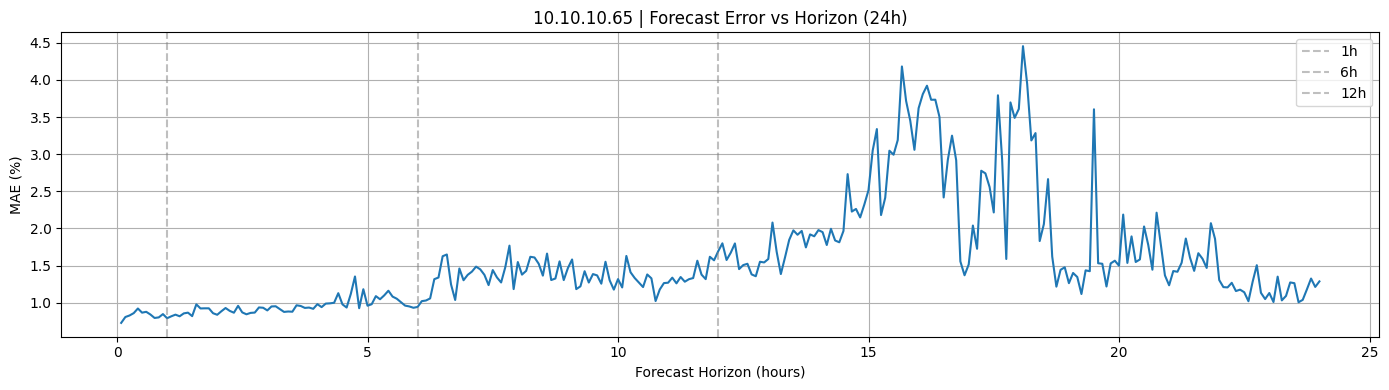

In [10]:
hours_axis = [(s + 1) * INTERVAL_MINS / 60 for s in range(FORECAST_HORIZON)]

plt.figure(figsize=(14, 4))
plt.plot(hours_axis, horizon_mae, linewidth=1.5)
for h in [1, 6, 12]:
    plt.axvline(x=h, color='gray', linestyle='--', alpha=0.5, label=f'{h}h')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('MAE (%)')
plt.title(f'{SERVER_NAME} | Forecast Error vs Horizon (24h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

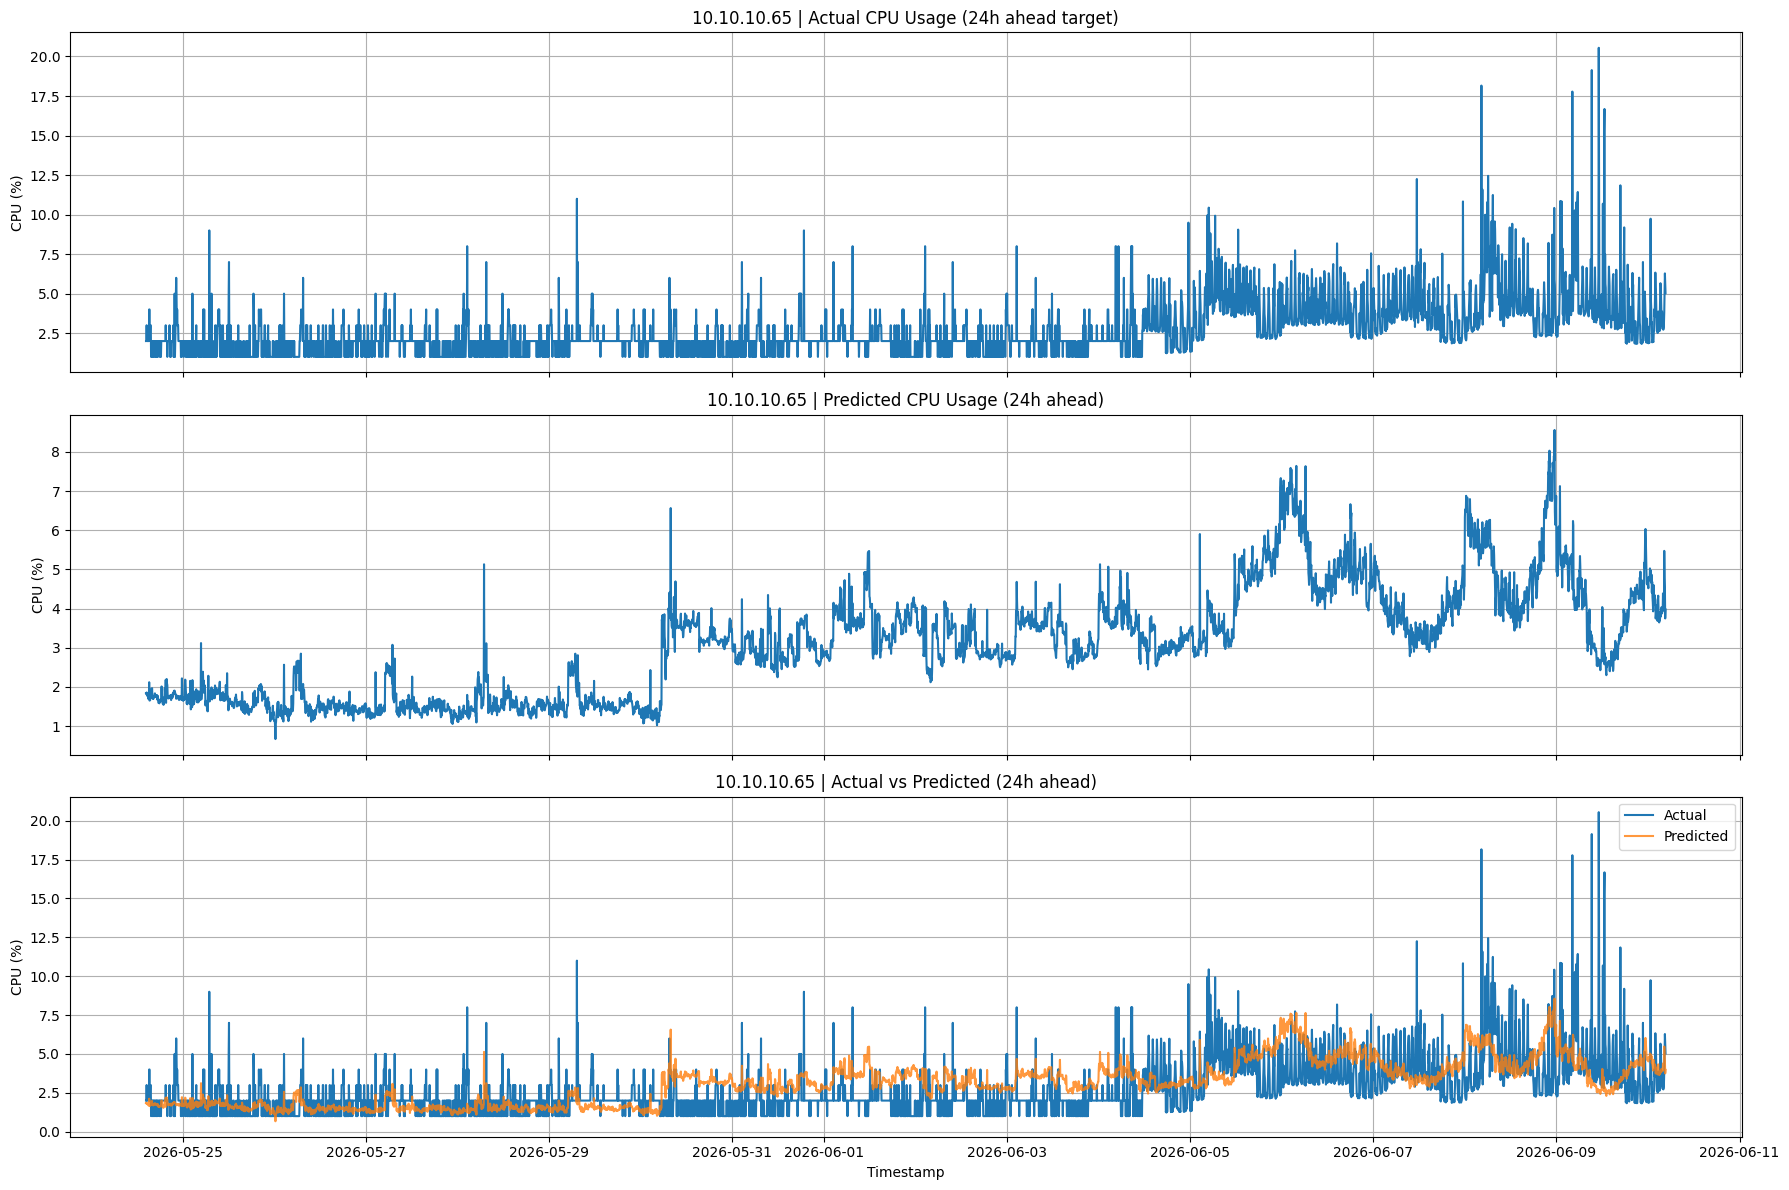

In [11]:
actual_24h    = Y_test.iloc[:, -1]
predicted_24h = predictions[:, -1]

results_24h = pd.DataFrame({
    'Timestamp'     : test_df['ts'].values,
    'Actual_24h'    : actual_24h.values,
    'Predicted_24h' : predicted_24h
})

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

axes[0].plot(results_24h['Timestamp'], results_24h['Actual_24h'])
axes[0].set_title(f'{SERVER_NAME} | Actual CPU Usage (24h ahead target)')
axes[0].set_ylabel('CPU (%)')
axes[0].grid(True)

axes[1].plot(results_24h['Timestamp'], results_24h['Predicted_24h'])
axes[1].set_title(f'{SERVER_NAME} | Predicted CPU Usage (24h ahead)')
axes[1].set_ylabel('CPU (%)')
axes[1].grid(True)

axes[2].plot(results_24h['Timestamp'], results_24h['Actual_24h'],    label='Actual')
axes[2].plot(results_24h['Timestamp'], results_24h['Predicted_24h'], label='Predicted', alpha=0.8)
axes[2].set_title(f'{SERVER_NAME} | Actual vs Predicted (24h ahead)')
axes[2].set_ylabel('CPU (%)')
axes[2].set_xlabel('Timestamp')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

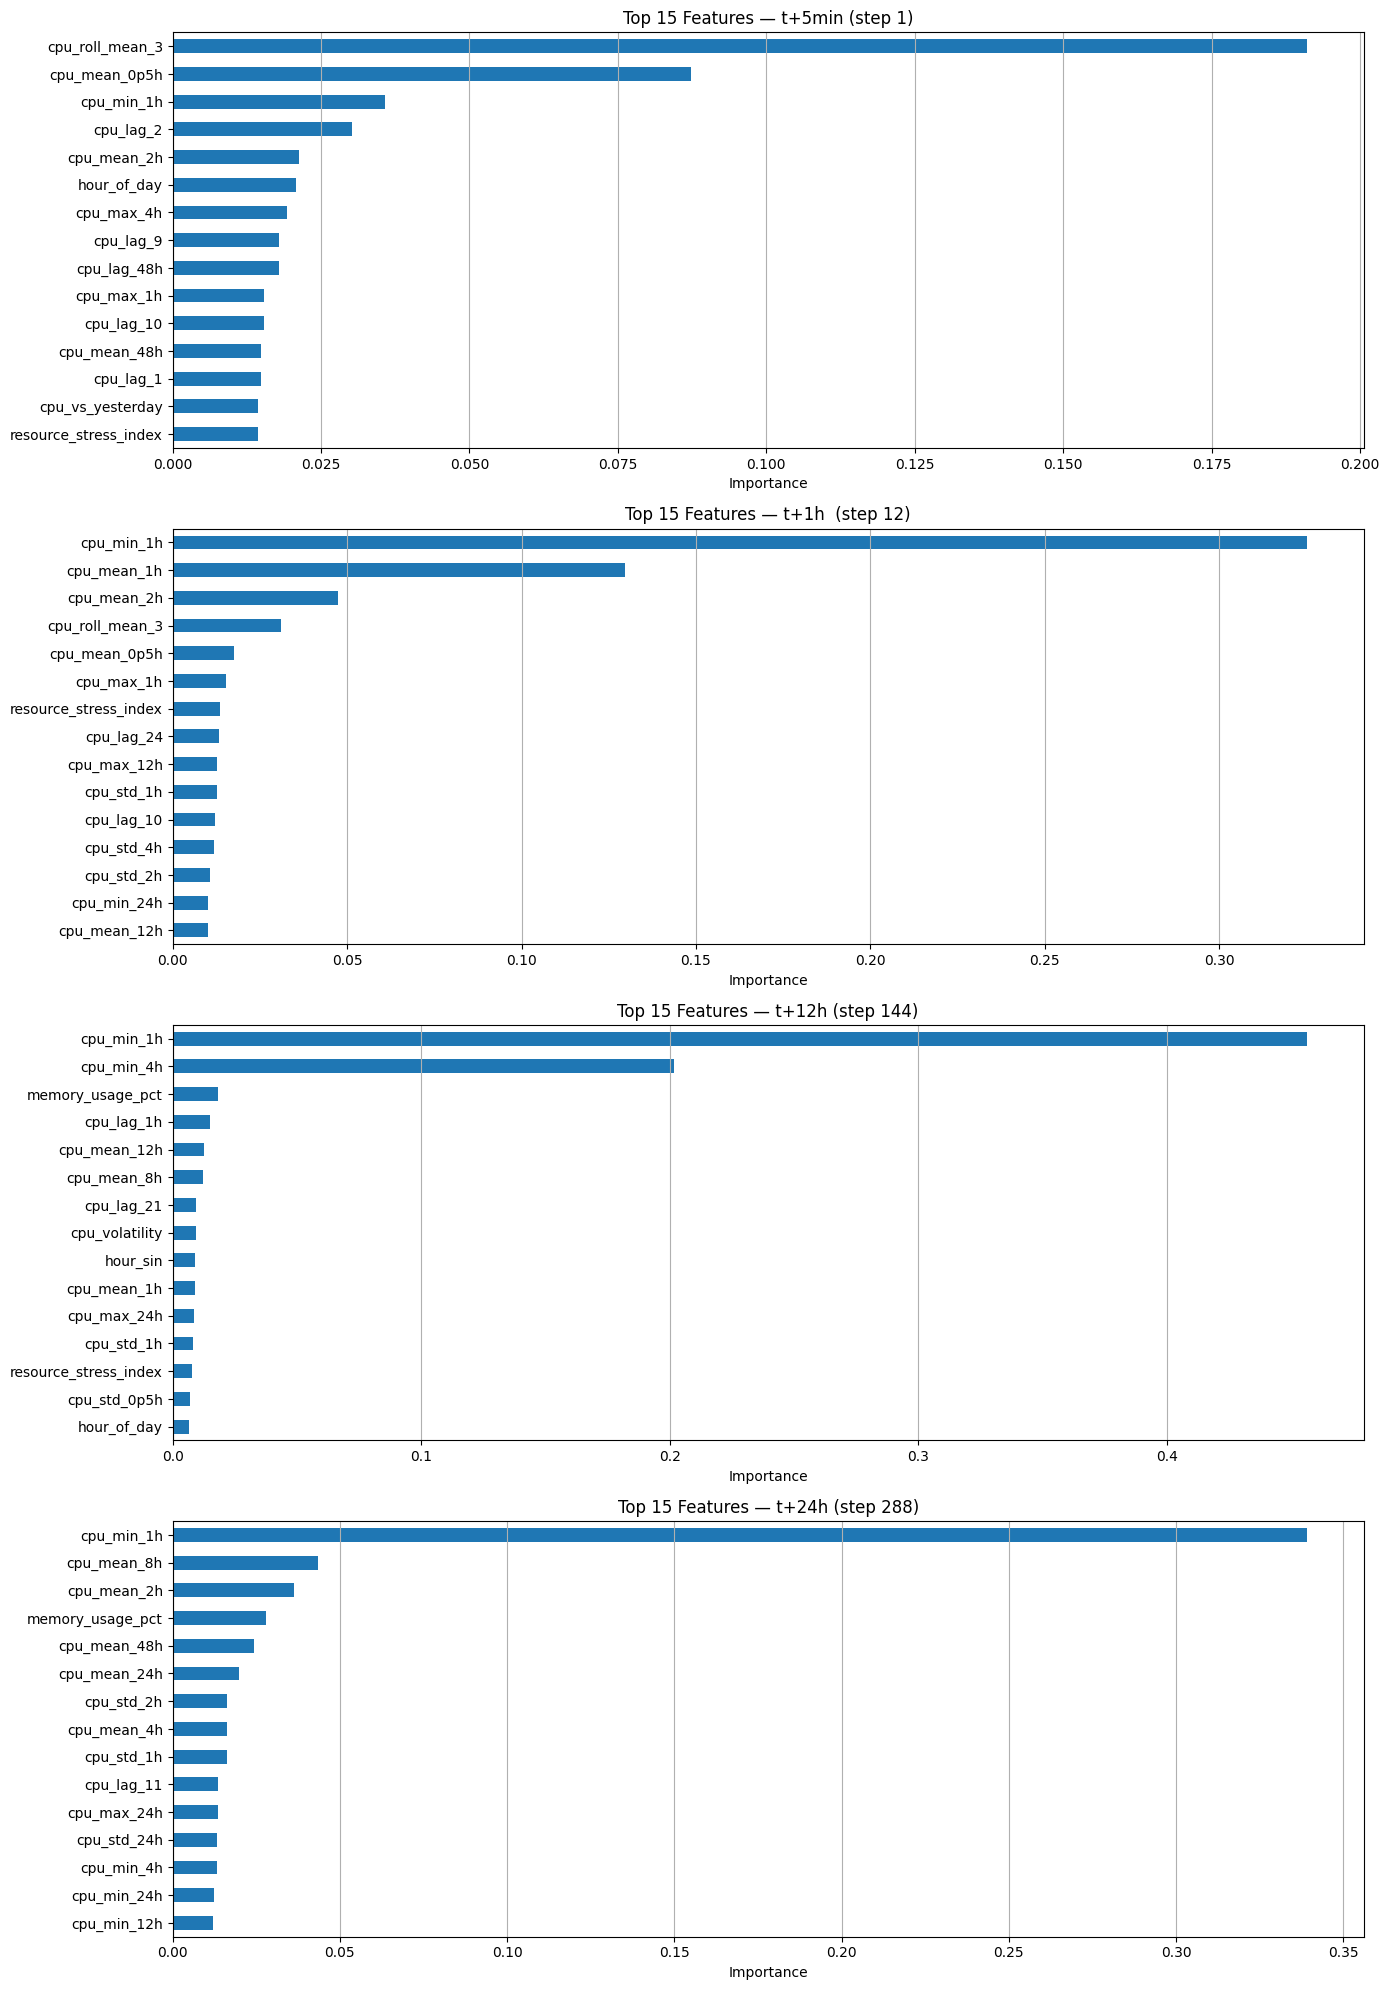

In [12]:
# Feature importance at 4 representative forecast steps
sample_steps = {
    't+5min (step 1)'  : 0,
    't+1h  (step 12)'  : 11,
    't+12h (step 144)' : 143,
    't+24h (step 288)' : 287,
}

TOP_N = 15
fig, axes = plt.subplots(len(sample_steps), 1, figsize=(14, 5 * len(sample_steps)))

for ax, (label, idx) in zip(axes, sample_steps.items()):
    imp = pd.Series(
        multi_model.estimators_[idx].feature_importances_,
        index=FEATURES
    ).nlargest(TOP_N)
    imp[::-1].plot(kind='barh', ax=ax)
    ax.set_title(f'Top {TOP_N} Features — {label}')
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

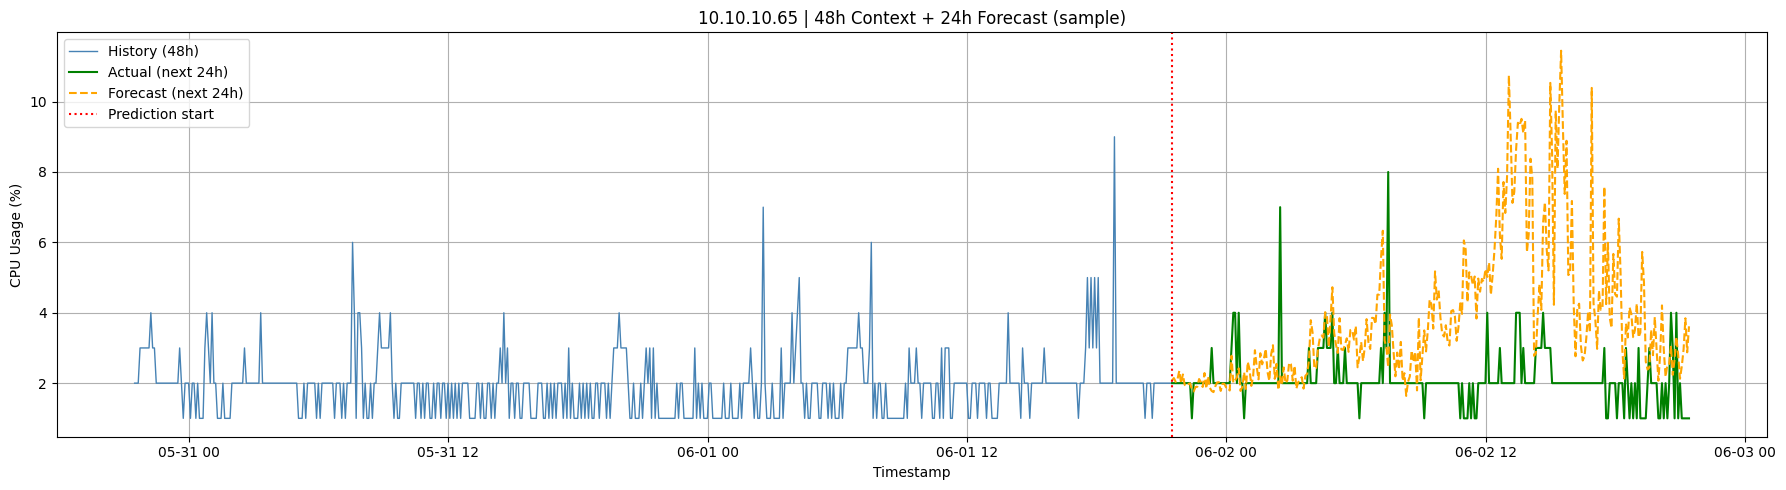

In [13]:
# Fan chart: visualise full 24h forecast for one sample window
SAMPLE_IDX = len(test_df) // 2

sample_pred   = predictions[SAMPLE_IDX]
sample_actual = Y_test.iloc[SAMPLE_IDX].values
forecast_ts   = pd.date_range(
    start  = test_df['ts'].iloc[SAMPLE_IDX],
    periods= FORECAST_HORIZON,
    freq   = f'{INTERVAL_MINS}min'
)

hist_end   = test_df.index[SAMPLE_IDX]
hist_start = max(0, hist_end - 48 * STEPS_PER_HOUR)
history_ts  = df.loc[hist_start:hist_end, 'ts']
history_cpu = df.loc[hist_start:hist_end, 'cpu_usage_pct']

plt.figure(figsize=(18, 5))
plt.plot(history_ts, history_cpu,  color='steelblue', label='History (48h)', linewidth=1)
plt.plot(forecast_ts, sample_actual, color='green',   label='Actual (next 24h)',   linewidth=1.5)
plt.plot(forecast_ts, sample_pred,   color='orange',  label='Forecast (next 24h)', linewidth=1.5, linestyle='--')
plt.axvline(x=df.loc[hist_end, 'ts'], color='red', linestyle=':', label='Prediction start')
plt.title(f'{SERVER_NAME} | 48h Context + 24h Forecast (sample)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
print("=" * 50)
print("24-Hour Forecast — Summary")
print("=" * 50)
print(f"Total features    : {len(FEATURES)}")
print(f"  Short lags      : {len(LAG_FEATURES)} (last 2h)")
print(f"  Hourly anchors  : {len(HOURLY_ANCHORS)}")
print(f"  Rolling stats   : {len(ROLLING_FEATURES)}")
print(f"  Slopes          : {len(SLOPE_FEATURES)}")
print(f"  Temporal        : {len(TEMPORAL_FEATURES)}")
print(f"  System metrics  : {len(SYSTEM_FEATURES)}")
print()
print(f"Overall MAE       : {overall_mae:.4f}%")
print(f"Overall RMSE      : {overall_rmse:.4f}%")
print(f"Overall R2        : {overall_r2:.4f}")
print("=" * 50)

24-Hour Forecast — Summary
Total features    : 73
  Short lags      : 24 (last 2h)
  Hourly anchors  : 6
  Rolling stats   : 24
  Slopes          : 3
  Temporal        : 7
  System metrics  : 8

Overall MAE       : 1.5754%
Overall RMSE      : 2.3845%
Overall R2        : -0.9902
